# Exploración del Modelo Logistico

----------
----------
##1. Construyendo un modelo logistico a partir de los datos
----------
----------

En un estudio sobre la propagación de una enfermedad en una población, se recopilaron datos sobre el número de personas infectadas en diferentes momentos.


| Tiempo (días) | Personas infectadas |
|---------------|---------------------|
|0 	|1.000000
|1 	|1.719000
|2 	|2.953725
|3 	|5.071683
|4 	|8.697572
|5 	|14.884176
|6 	|25.379244
|7 	|43.008194
|8 	|72.124389
|9 	|118.852022
|10 |190.299675
|11 |291.101474
|12 |415.954468
|13 |542.423565
|14 |638.745208
|15 |690.646317



<br>

Con la información anterior  realize lo siguiente:

<br>

1. Grafique los datos de la tabla.

2. Asumiendo que los datos satisfacen un modelo logistico de la forma
<br>

  $$P_{n+1} = \left(\kappa  - \beta\, P_n \right) P_{n}$$
  Utilize una regresion lineal que le permita encontrar los parametros del modelo tal que prediga los datos de la tabla.

<br>

<br>

3. Realice un gráfico en el cual se muestre el comportamiento del modelo para diferentes valores de la constante $\beta$. En particular, muestre las predicciones del modelo en un mismo gráfico para $\beta = 0.001$, $\beta = 0.005$ y $\beta = 0.1$. Utilice para la constante $\kappa$ el mismo valor predicho por la linealización de los datos del punto 2. Explique sus observaciones en un párrafo.

<br>

4. Realice un gráfico en el cual se muestre el comportamiento del modelo para diferentes valores de la constante $\kappa$. En particular, muestre las predicciones del modelo en un mismo gráfico para $\kappa = 2.0$, $\kappa = 2.8$, $\kappa = 3.0$ y $\kappa = 3.5$. Utilice para la constante $\beta$ el mismo valor predicho por la linealización de los datos del punto 2. Explique sus observaciones en un párrafo.

**Solución**

**1:**

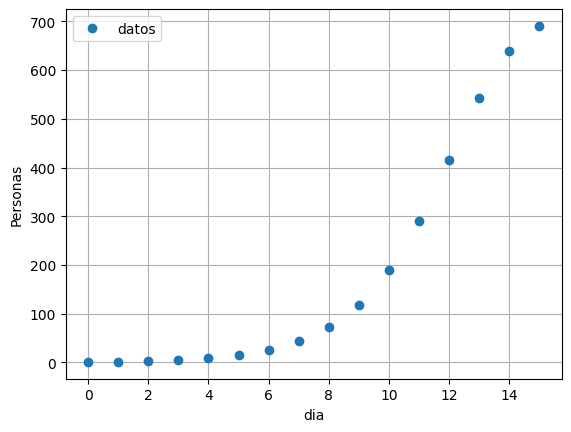

In [26]:
import numpy as np
import matplotlib.pyplot as plt


tiempo_dias = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,11,12,13,14,15])
personas_infectadas = np.array([ 1.000000,
1.719000,
2.953725,
5.071683,
8.697572,
14.884176,
25.379244,
43.008194,
72.124389,
118.852022,
190.299675,
291.101474,
415.954468,
542.423565,
638.745208,
690.646317])




plt.plot( tiempo_dias, personas_infectadas , 'o' , label='datos' )
plt.xlabel('dia')
plt.ylabel('Personas')
plt.legend()
plt.grid()
plt.show()


2.

Suponiendo un modelo logistico de la forma
$$P_{n+1} = \left(\kappa  - \beta\, P_n \right) P_{n}$$
con $\beta$ y $\kappa$ parametros, se puede demostrar que

  $$
\dfrac{\Delta P_n}{P_n}  = - \beta P_n + (\kappa - 1), $$

Lo cual es una recta de $\dfrac{\Delta P_n}{P_n}$ contra $P_{n}$. por tanto, si aplicamos una regresion lineal sobre la recta podremos hallar los parametros del modelo.

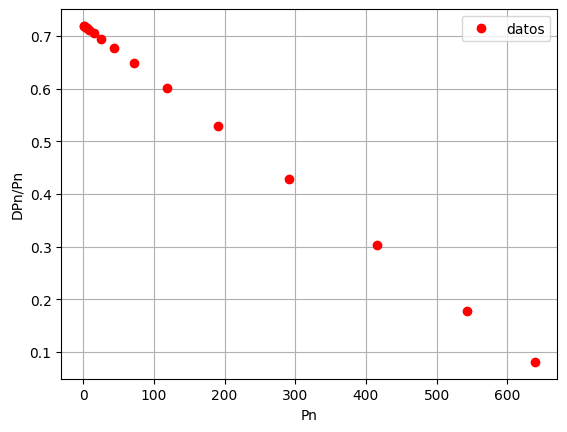

In [27]:
#Pasamos la lista Pn a arraglo!
Pn= np.array(personas_infectadas)


#Definimos numericamente DPn
DPn = Pn[1:] - Pn[0:-1]


#Definimos el cocientey
DPnPn= DPn/Pn[0:-1] #Ojo con el -2 en el arreglo, esto es para excluir el ultimo termino!


plt.plot( Pn[0:-1] , DPnPn , 'ro' , label='datos' )
plt.xlabel('Pn')
plt.ylabel('DPn/Pn')
plt.legend()
plt.grid()
plt.show()

Con lo que podemos hacer una regresion lineal para encontrar k y $\beta$ mediante una regresion lineal



In [28]:
from scipy import stats   # Carga el módulo de herramientas estadísticas


#Haciendo la regresion lineal con scipy
regresion_lineal = stats.linregress(Pn[0:-1] , DPnPn)

# Resultados del análisis
k    = regresion_lineal.intercept + 1  # Intercepto
beta = -1 * regresion_lineal.slope       # Pendiente


print("el valor de los parametros del modelo es  k= ", k, ', beta= ',beta)

el valor de los parametros del modelo es  k=  1.7199999997176127 , beta=  0.000999999998945956


Veamos que en efecto, estos parametros permiten describir los datos de la tabla:


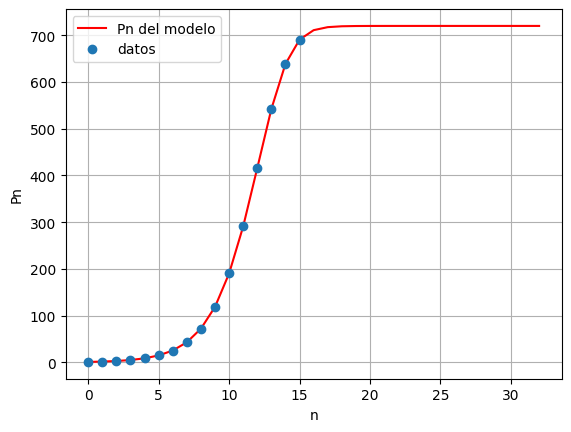

In [29]:

#Modelo de ecuacion logistica
def Pn(n):
    #definimos el valor inicial
    Pn=[1]

    for i in range(n):

        Pn.append( Pn[i] * (k  - beta * Pn[i]) )

    return Pn

Pn_puntos = Pn(32)
n_puntos  = [i for i in range( len(Pn_puntos ) )]



plt.plot( n_puntos, Pn_puntos , '-' , color='red', label= 'Pn del modelo')

plt.plot( tiempo_dias, personas_infectadas , 'o' , label='datos' )



"""
#Modelo de ecuacion exponencial
def Pne(n):
    #definimos el valor inicial
    Pn=[1]

    for i in range(n):

        Pn.append( Pn[i] * (k   ) )

    return Pn

Pn_puntos_expo = Pne(32)
plt.plot( n_puntos, Pn_puntos_expo , '-' , color='blue', label= 'Pn ')
"""



plt.xlabel('n')
plt.ylabel('Pn')
plt.legend()
plt.grid()

plt.show()





3.

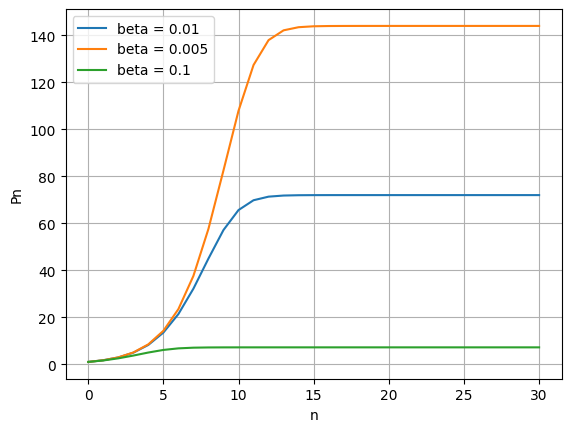

In [31]:
def Pn(n, beta):
    #definimos el valor inicial
    Pn=[1]

    kappa = 1.72

    for i in range(n):

        Pn.append( Pn[i] * (kappa - beta * Pn[i]) )

    return Pn



Lista_de_beta = np.array([ 0.01,0.005,0.1 ])


for beta in Lista_de_beta:

  Pn_puntos = Pn(30,beta)

  n_puntos  = [i for i in range( len(Pn_puntos ) )]

  plt.plot( n_puntos, Pn_puntos ,  label= 'beta = ' + str(beta) )


plt.xlabel('n')
plt.ylabel('Pn')
plt.legend()
plt.grid()

plt.show()

Se observa que si la capacidad de carga aumenta, entonces no da paso a que la poblacion cresca, lo cual tiene sentido ya que esto representa las restriciones de crecimiento que el ambiente impone sobre la poblacion.

4.

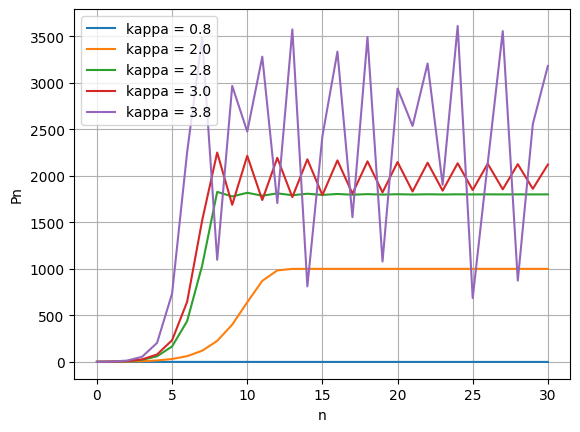

In [ ]:
def Pn(n, kappa):
    #definimos el valor inicial
    Pn=[1]

    beta = 0.001

    for i in range(n):

        Pn.append( Pn[i] * (kappa - beta * Pn[i]) )

    return Pn



Lista_de_kappa = np.array([ 0.8, 2.0, 2.8 , 3. , 3.8 ])


for kappa in Lista_de_kappa:

  Pn_puntos = Pn(30,kappa)

  n_puntos  = [i for i in range( len(Pn_puntos ) )]

  plt.plot( n_puntos, Pn_puntos ,  label= 'kappa = ' + str(kappa) )


plt.xlabel('n')
plt.ylabel('Pn')
plt.legend()
plt.grid()

plt.show()

Se observa que si la tasa de crecimiento crece, entonces el modelo ya no converge hacia una solución. Esto se puede explicar por punto fijo, pero no se exigira al estudiante.

---------------
---------------
# Caos y la ecuación logistica
--------------
--------------


En matemáticas, caos se refiere a un tipo de comportamiento dinámico que surge en ciertos sistemas deterministas, pero que parece aleatorio e impredecible a simple vista.Más formalmente, hablamos de caos determinista en el contexto de los sistemas dinámicos. Un sistema caótico se caracteriza por:

<br>

Determinismo:

  - Las reglas que gobiernan el sistema no tienen azar, están perfectamente definidas (por ejemplo, una ecuación diferencial o una recurrencia).

  - Sensibilidad a las condiciones iniciales:
  Pequeñas diferencias en el estado inicial producen trayectorias muy diferentes con el paso del tiempo. Esto es lo que se suele llamar el efecto mariposa.


<br>

**Ejemplo: La ecuacion logistica!**


La ecuación logística discreta es ampliamente utilizada en la modelización de sistemas dinámicos discretos, como la dinámica de poblaciones en ecología, la dinámica de precios en economía, y en sistemas caóticos y fractales.

La ecuación logística tiene **bifurcaciones** en su comportamiento debido a su naturaleza no lineal y al cambio en su comportamiento dinámico a medida que varían los parámetros, como la tasa de crecimiento $\kappa$ y la capacidad de carga $\beta$.

<br>

Las bifurcaciones ocurren cuando pequeños cambios en los parámetros resultan en cambios drásticos en el comportamiento del sistema. En el caso de la ecuación logística, estas bifurcaciones pueden manifestarse como cambios en el número y estabilidad de los puntos fijos, la aparición de ciclos límite o comportamiento caótico.



# Ejemplo de bifurcacion (caos)

Un punto fijo en un sistema dinámico es un estado en el que la evolución del sistema se detiene, es decir, el valor de la variable o variables del sistema no cambia con el tiempo. En el contexto de la ecuación logística, un punto fijo sería un valor de la población en el que la tasa de cambio de la población es cero.


Veamos la bifurcacion de la sucesion de recurrencia

<br>

$$\boxed{x_{n+1} = \left(  1 - x_n \right) r \ x_{n}}$$

<br>

La cual tiene la forma de la ecuacion logistica $P_{n+1} = \left(\kappa  - \beta\, P_n \right) P_{n}$.

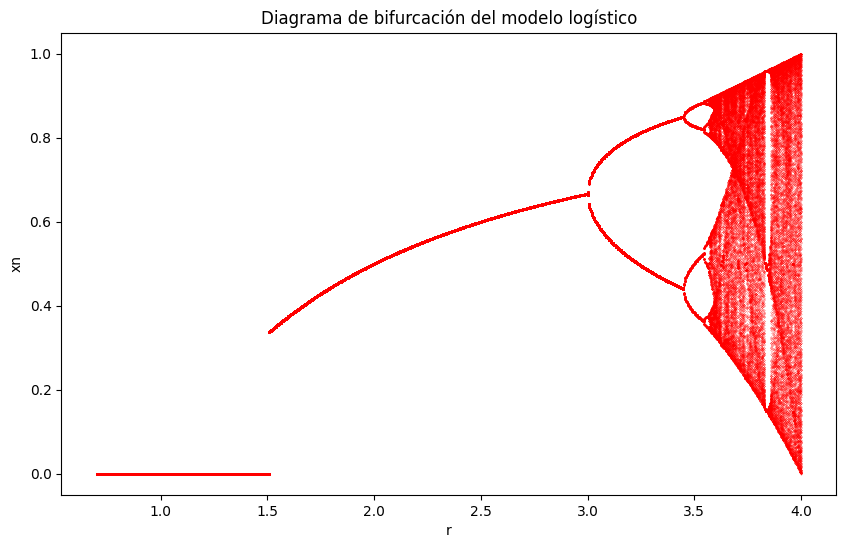

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
r_values = np.linspace(0.7, 4.0 , 1000 )  # Rango de valores de r
x = 0.5  # Valor inicial de x

num_iterations = 500  # Número de iteraciones para alcanzar el equilibrio
num_points = 400     # Número de puntos a graficar

bifurcation_diagram = []

# Calcular el diagrama de bifurcación
for r in r_values:

    # Número de iteraciones para alcanzar un supesto punto de equilibrio de x_n en el r
    for _ in range(num_iterations):
        x = r * x * (1 - x)

    #Desde el punto fijo hallado, se continua la iteracion para ver si cambia! Se guardan los valores.
    for _ in range(num_points):

        x = r * x * (1 - x)
        bifurcation_diagram.append([r, x])


#diagrama de bifurcacion!
bifurcation_diagram = np.array(bifurcation_diagram)

# Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(bifurcation_diagram[:, 0], bifurcation_diagram[:, 1], s=0.1, c='red', marker='.')
plt.title('Diagrama de bifurcación del modelo logístico')
plt.xlabel('r')
plt.ylabel('xn')
plt.show()